In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
poker_hand = fetch_ucirepo(id=158) 
  
# data (as pandas dataframes) 
X = poker_hand.data.features 
y = poker_hand.data.targets 
  
# metadata 
print(poker_hand.metadata) 
  
# variable information 
print(poker_hand.variables) 


{'uci_id': 158, 'name': 'Poker Hand', 'repository_url': 'https://archive.ics.uci.edu/dataset/158/poker+hand', 'data_url': 'https://archive.ics.uci.edu/static/public/158/data.csv', 'abstract': 'Purpose is to predict poker hands', 'area': 'Games', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1025010, 'num_features': 10, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['CLASS'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2002, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5KW38', 'creators': ['Robert Cattral', 'Franz Oppacher'], 'intro_paper': None, 'additional_info': {'summary': 'Each record is an example of a hand consisting of five playing cards drawn from a standard deck of 52. Each card is described using two attributes (suit and rank), for a total of 10 predictive attributes. There is one Class attribute that describes the "Poker Hand". T

   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5
0   1  10   1  11   1  13   1  12   1   1
1   2  11   2  13   2  10   2  12   2   1
2   3  12   3  11   3  13   3  10   3   1
3   4  10   4  11   4   1   4  13   4  12
4   4   1   4  13   4  12   4  11   4  10
   CLASS
0      9
1      9
2      9
3      9
4      9


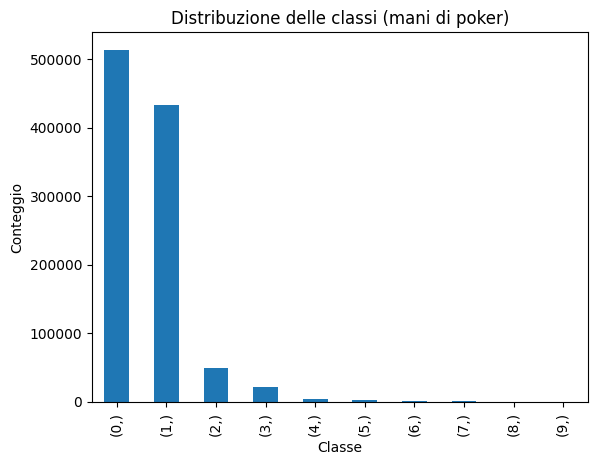

                 S1            C1            S2            C2            S3  \
count  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06   
mean   2.500695e+00  6.997861e+00  2.499841e+00  7.006295e+00  2.501100e+00   
std    1.117737e+00  3.743529e+00  1.118646e+00  3.744054e+00  1.118345e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
25%    2.000000e+00  4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00   
50%    3.000000e+00  7.000000e+00  2.000000e+00  7.000000e+00  3.000000e+00   
75%    3.000000e+00  1.000000e+01  4.000000e+00  1.000000e+01  4.000000e+00   
max    4.000000e+00  1.300000e+01  4.000000e+00  1.300000e+01  4.000000e+00   

                 C3            S4            C4            S5            C5  
count  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06  1.025010e+06  
mean   6.999246e+00  2.500284e+00  7.000838e+00  2.499399e+00  6.988828e+00  
std    3.741964e+00  1.117215e+00  3.741423e+00  1.118

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dai un'occhiata alle prime righe
print(X.head())
print(y.head())

# Distribuzione della classe target
y.value_counts().plot(kind='bar')
plt.title("Distribution of the classes (poker hands)")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

# Statistiche di base
print(X.describe())


In [ ]:
from sklearn.model_selection import train_test_split

# Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Dimension:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Dimensioni:
Train: (717507, 10)
Validation: (153751, 10)
Test: (153752, 10)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# assicurati che y_train sia 1D
y_train_1d = np.asarray(y_train).ravel()

# prendi l’insieme completo delle classi (meglio da tutto y, non solo dal train)
all_classes = np.unique(np.asarray(y).ravel())

# calcola i pesi
weights = compute_class_weight(class_weight='balanced',
                               classes=all_classes,
                               y=y_train_1d)

class_weights = dict(zip(all_classes, weights))
print("Balanced class weights:", class_weights)


Pesi bilanciati per classe: {np.int64(0): np.float64(0.1995341930137295), np.int64(1): np.float64(0.23666976725775807), np.int64(2): np.float64(2.099262705169841), np.int64(3): np.float64(4.7378961965134705), np.int64(4): np.float64(25.76326750448833), np.int64(5): np.float64(50.00048780487805), np.int64(6): np.float64(70.20616438356164), np.int64(7): np.float64(434.8527272727273), np.int64(8): np.float64(5979.225), np.int64(9): np.float64(11958.45)}


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("\n--- CV: Regressione Logistica (Softmax) ---")
logreg_base = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1,
    class_weight=class_weights # Uso dei pesi bilanciati
)

param_grid_logreg = {
    'C': [0.1, 1.0, 10.0]
}

grid_search_logreg = GridSearchCV(
    estimator=logreg_base,
    param_grid=param_grid_logreg,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_logreg.fit(X_train_scaled, y_train_1d)
logreg_best_cv = grid_search_logreg.best_estimator_

print("LogReg - Parametri ottimali:", grid_search_logreg.best_params_)
print("LogReg - Miglior F1 Macro su CV:", grid_search_logreg.best_score_)


--- CV: Regressione Logistica (Softmax) ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

LogReg - Parametri ottimali: {'C': 0.1}
LogReg - Miglior F1 Macro su CV: 0.04353192245891521


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
from sklearn.tree import DecisionTreeClassifier

print("\n--- CV: Albero di Decisione ---")
dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight=class_weights # Uso dei pesi bilanciati
)

param_grid_dt = {
    'max_depth': [15, 20, 25],
    'min_samples_leaf': [5, 10, 15]
}

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_dt.fit(X_train_scaled, y_train_1d)
dt_best_cv = grid_search_dt.best_estimator_

print("DT - Parametri ottimali:", grid_search_dt.best_params_)
print("DT - Miglior F1 Macro su CV:", grid_search_dt.best_score_)


--- CV: Albero di Decisione ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits
DT - Parametri ottimali: {'max_depth': 25, 'min_samples_leaf': 5}
DT - Miglior F1 Macro su CV: 0.20351844439577063


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Definizione dei parametri da ottimizzare (Hyperparameter Grid)
# Stiamo limitando il range per velocizzare l'esempio, puoi espanderlo.
param_grid = {
    'max_depth': [18, 20, 22],
    'min_samples_leaf': [8, 10, 12],
    'n_estimators': [100, 200]
}

# 2. Re-definiamo il modello base senza i parametri di regolarizzazione,
#    che saranno impostati dalla CV.
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights # Manteniamo i pesi bilanciati
)

# 3. Configurazione della Cross-Validation
# Usiamo 'f1_macro' come metrica di scoring per l'ottimizzazione (per lo sbilanciamento)
# cv=3 indica 3-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# 4. Esecuzione del Training con Cross-Validation (sul solo set di Training)
# Nota: L'addestramento qui avverrà 3 volte per ogni combinazione di iperparametri.
# Questo può richiedere molto tempo con un dataset così grande.
print("Starting the Cross-Validation...")
grid_search.fit(X_train_scaled, y_train.values.ravel())

# 5. Otteniamo il miglior modello
rf_best_cv = grid_search.best_estimator_
print("\nOptimal parameters found:", grid_search.best_params_)
print("Best Macro F1 score on CV:", grid_search.best_score_)

# Ora, usa 'rf_best_cv' per la valutazione su X_val_scaled e X_test_scaled

Starting the Cross-Validation...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END max_depth=18, min_samples_leaf=10, n_estimators=100; total time= 1.1min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=100; total time= 1.1min
[CV] END max_depth=18, min_samples_leaf=10, n_estimators=100; total time= 1.1min
[CV] END max_depth=18, min_samples_leaf=10, n_estimators=100; total time= 1.1min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=100; total time= 1.1min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=100; total time= 1.1min
[CV] END max_depth=18, min_samples_leaf=10, n_estimators=200; total time= 2.1min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=200; total time= 2.2min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=200; total time= 2.2min
[CV] END max_depth=18, min_samples_leaf=12, n_estimators=100; total time= 1.1min
[CV] END .max_depth=18, min_samples_leaf=8, n_estimators=200; total time= 2.2min
[CV] END max_de

/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=18, min_samples_leaf=10, n_estimators=200; total time= 2.3min
[CV] END max_depth=18, min_samples_leaf=12, n_estimators=200; total time= 2.2min
[CV] END max_depth=18, min_samples_leaf=10, n_estimators=200; total time= 2.3min
[CV] END .max_depth=20, min_samples_leaf=8, n_estimators=100; total time= 1.3min
[CV] END .max_depth=20, min_samples_leaf=8, n_estimators=100; total time= 1.3min
[CV] END .max_depth=20, min_samples_leaf=8, n_estimators=100; total time= 1.3min
[CV] END max_depth=18, min_samples_leaf=12, n_estimators=200; total time= 2.4min
[CV] END max_depth=18, min_samples_leaf=12, n_estimators=200; total time= 2.4min
[CV] END max_depth=20, min_samples_leaf=10, n_estimators=100; total time= 1.3min
[CV] END max_depth=20, min_samples_leaf=10, n_estimators=100; total time= 1.3min
[CV] END .max_depth=20, min_samples_leaf=8, n_estimators=200; total time= 2.6min
[CV] END max_depth=20, min_samples_leaf=10, n_estimators=100; total time= 1.3min
[CV] END .max_depth=20, min_

In [25]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Inizializzazione della lista per i risultati finali
final_results = []
models_to_test = [
    ("Logistic (CV)", logreg_best_cv),
    ("Decision Tree (CV)", dt_best_cv),
    ("Random Forest (CV)", rf_best_cv)
]

print("\n--- VALUTAZIONE FINALE SU TEST SET (Modelli CV Ottimizzati) ---")

for name, model in models_to_test:
    # Previsioni sul set di Test
    y_pred_test = model.predict(X_test_scaled)
    
    # Calcolo delle metriche
    acc = accuracy_score(y_test, y_pred_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    f1_macro = f1_score(y_test, y_pred_test, average='macro')
    
    # Stampa i risultati per il report
    print(f"\nModello: {name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Balanced Accuracy: {bal_acc:.4f}")
    print(f"  Macro F1: {f1_macro:.4f}")
    
    final_results.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced Accuracy': bal_acc,
        'Macro F1': f1_macro
    })

# Converti in DataFrame per una visualizzazione chiara (opzionale)
results_df = pd.DataFrame(final_results)
print("\nTABELLA COMPARATIVA FINALE:")
print(results_df.sort_values(by='Balanced Accuracy', ascending=False))


--- VALUTAZIONE FINALE SU TEST SET (Modelli CV Ottimizzati) ---

Modello: Logistic (CV)
  Accuracy: 0.0935
  Balanced Accuracy: 0.0872
  Macro F1: 0.0397

Modello: Decision Tree (CV)
  Accuracy: 0.5757
  Balanced Accuracy: 0.3010
  Macro F1: 0.2153

Modello: Random Forest (CV)
  Accuracy: 0.6929
  Balanced Accuracy: 0.4029
  Macro F1: 0.3479

TABELLA COMPARATIVA FINALE:
                Model  Accuracy  Balanced Accuracy  Macro F1
2  Random Forest (CV)  0.692915           0.402873  0.347910
1  Decision Tree (CV)  0.575661           0.301044  0.215339
0       Logistic (CV)  0.093547           0.087250  0.039719


In [9]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight=class_weights)

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, class_weight=class_weights)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                            class_weight=class_weights)

from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1, gamma='scale', class_weight=class_weights,
          random_state=42)


In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

def eval_model(name, model, X_tr, y_tr, X_va, y_va):
    y_pred = model.predict(X_va)
    print(f"\n=== {name} ===")
    print("Balanced accuracy:", balanced_accuracy_score(y_va, y_pred))
    print("Macro F1:", f1_score(y_va, y_pred, average='macro'))
    print(classification_report(y_va, y_pred, digits=3))
    return y_pred


# ASSUMIAMO che 'rf_best_cv' sia il modello ottimale trovato dalla GridSearchCV
# ASSUMIAMO che 'X_test_scaled' e 'y_test' siano i set di dati di Test scalati

# Eseguiamo la valutazione finale sul set di TEST
print("\n--- ESECUZIONE DEL REPORT DI CLASSIFICAZIONE SUL TEST SET FINALE ---")

# Chiamiamo la tua funzione eval_model, ma usiamo X_test_scaled e y_test
# Nota: passiamo X_train_scaled e y_train per gli argomenti X_tr e y_tr, anche se non usati dalla funzione
# questo mantiene la struttura della funzione che avevi definito
y_pred_test = eval_model(
    name="Random Forest (CV Optimized) - FINAL TEST",
    model=rf_best_cv,
    X_tr=X_train_scaled,  # Dati di Training (usati solo come placeholder qui)
    y_tr=y_train,         # Etichette di Training (placeholder)
    X_va=X_test_scaled,   # Dati di VALIDAZIONE REALI (il TEST set)
    y_va=y_test           # Etichette di VALIDAZIONE REALI
)

# La variabile y_pred_test ora contiene le predizioni per il set di Test
# che puoi usare per generare la Matrice di Confusione


--- ESECUZIONE DEL REPORT DI CLASSIFICAZIONE SUL TEST SET FINALE ---

=== Random Forest (CV Optimized) - FINAL TEST ===
Balanced accuracy: 0.4028728137174891
Macro F1: 0.34791029853646027
              precision    recall  f1-score   support

           0      0.716     0.915     0.804     77056
           1      0.747     0.473     0.579     64965
           2      0.426     0.382     0.402      7325
           3      0.459     0.521     0.488      3245
           4      0.140     0.804     0.239       597
           5      0.909     0.883     0.896       307
           6      0.118     0.050     0.071       219
           7      0.000     0.000     0.000        35
           8      0.000     0.000     0.000         2
           9      0.000     0.000     0.000         1

    accuracy                          0.693    153752
   macro avg      0.352     0.403     0.348    153752
weighted avg      0.707     0.693     0.680    153752



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=200,            # alza se non converge
    multi_class='multinomial',
    solver='saga',           # supporta class_weight + multinomial
    class_weight=class_weights,
    n_jobs=-1
)
logreg.fit(X_train_scaled, y_train)
_ = eval_model("Logistic (Softmax)", logreg, X_train_scaled, y_train, X_val_scaled, y_val)


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic (Softmax) ===
Balanced accuracy: 0.08548552512505003
Macro F1: 0.032934543296343224
              precision    recall  f1-score   support

           0      0.468     0.099     0.163     77055
           1      0.453     0.030     0.055     64964
           2      0.050     0.200     0.079      7324
           3      0.016     0.005     0.007      3245
           4      0.010     0.076     0.018       596
           5      0.002     0.318     0.004       308
           6      0.001     0.073     0.002       219
           7      0.000     0.056     0.000        36
           8      0.000     0.000     0.000         3
           9      0.000     0.000     0.000         1

    accuracy                          0.073    153751
   macro avg      0.100     0.085     0.033    153751
weighted avg      0.429     0.073     0.109    153751



/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight=class_weights,  # usa i pesi bilanciati calcolati prima
    max_depth=None,              # lascialo crescere liberamente per ora
    min_samples_leaf=1
)

dt.fit(X_train_scaled, y_train)
_ = eval_model("Decision Tree", dt, X_train_scaled, y_train, X_val_scaled, y_val)



=== Decision Tree ===
Balanced accuracy: 0.2624933022455936
Macro F1: 0.2575790192217725
              precision    recall  f1-score   support

           0      0.746     0.743     0.745     77055
           1      0.629     0.628     0.629     64964
           2      0.292     0.291     0.291      7324
           3      0.333     0.356     0.344      3245
           4      0.232     0.220     0.226       596
           5      0.101     0.143     0.118       308
           6      0.106     0.132     0.118       219
           7      0.100     0.111     0.105        36
           8      0.000     0.000     0.000         3
           9      0.000     0.000     0.000         1

    accuracy                          0.661    153751
   macro avg      0.254     0.262     0.258    153751
weighted avg      0.662     0.661     0.661    153751



In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,          # numero di alberi, puoi aumentarlo se hai tempo
    random_state=42,
    n_jobs=-1,                 # usa tutti i core
    class_weight=class_weights # compensa lo sbilanciamento
)

rf.fit(X_train_scaled, y_train)
_ = eval_model("Random Forest", rf, X_train_scaled, y_train, X_val_scaled, y_val)


/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



=== Random Forest ===
Balanced accuracy: 0.1963462292598338
Macro F1: 0.21379117935101566
              precision    recall  f1-score   support

           0      0.779     0.916     0.842     77055
           1      0.723     0.697     0.709     64964
           2      0.585     0.022     0.042      7324
           3      0.828     0.053     0.100      3245
           4      0.636     0.012     0.023       596
           5      1.000     0.260     0.412       308
           6      0.333     0.005     0.009       219
           7      0.000     0.000     0.000        36
           8      0.000     0.000     0.000         3
           9      0.000     0.000     0.000         1

    accuracy                          0.756    153751
   macro avg      0.488     0.196     0.214    153751
weighted avg      0.746     0.756     0.727    153751



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_reg = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights,
    max_depth=20,          # limite la profondità massima
    min_samples_leaf=10,   # almeno 10 esempi per foglia
)
rf_reg.fit(X_train_scaled, y_train)
_ = eval_model("Random Forest (reg)", rf_reg, X_train_scaled, y_train, X_val_scaled, y_val)



/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



=== Random Forest (reg) ===
Balanced accuracy: 0.4082243507762879
Macro F1: 0.36776086422431664
              precision    recall  f1-score   support

           0      0.715     0.908     0.800     77055
           1      0.734     0.471     0.574     64964
           2      0.417     0.405     0.411      7324
           3      0.430     0.512     0.467      3245
           4      0.155     0.750     0.257       596
           5      0.960     0.847     0.900       308
           6      0.253     0.105     0.148       219
           7      0.214     0.083     0.120        36
           8      0.000     0.000     0.000         3
           9      0.000     0.000     0.000         1

    accuracy                          0.689    153751
   macro avg      0.388     0.408     0.368    153751
weighted avg      0.700     0.689     0.676    153751



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


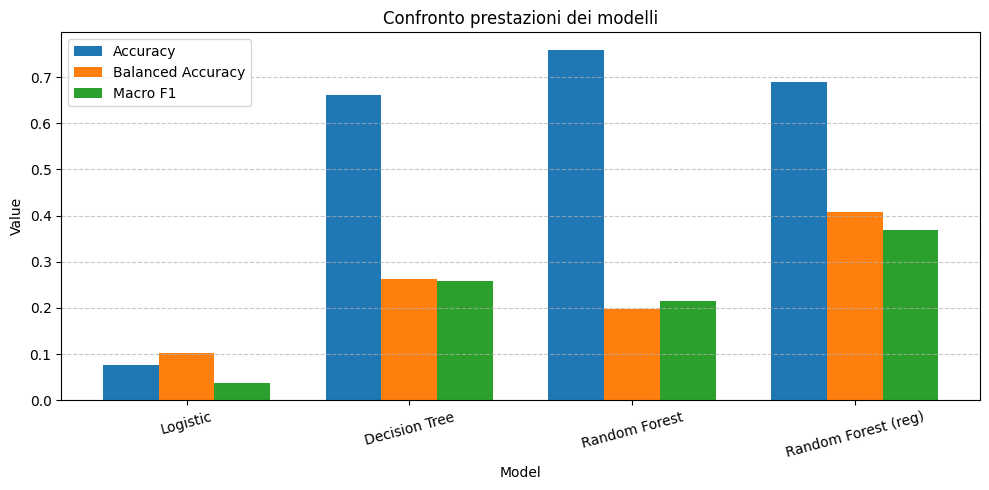

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Inserisci le metriche che hai ottenuto
models = ['Logistic', 'Decision Tree', 'Random Forest', 'Random Forest (reg)']
accuracy = [0.077, 0.661, 0.759, 0.689]
balanced_acc = [0.103, 0.262, 0.198, 0.408]
macro_f1 = [0.037, 0.258, 0.215, 0.368]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width, accuracy, width, label='Accuracy')
ax.bar(x, balanced_acc, width, label='Balanced Accuracy')
ax.bar(x + width, macro_f1, width, label='Macro F1')

ax.set_xlabel('Model')
ax.set_ylabel('Value')
ax.set_title('Model performance comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

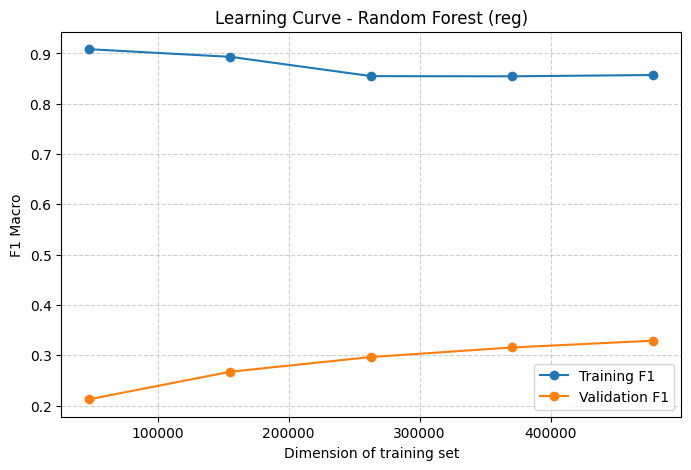

In [16]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_reg,
    X_train_scaled,
    y_train,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Training F1')
plt.plot(train_sizes, val_mean, 'o-', label='Validation F1')
plt.title('Learning Curve - Random Forest (reg)')
plt.xlabel('Dimension of training set')
plt.ylabel('F1 Macro')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


<Figure size 800x800 with 0 Axes>

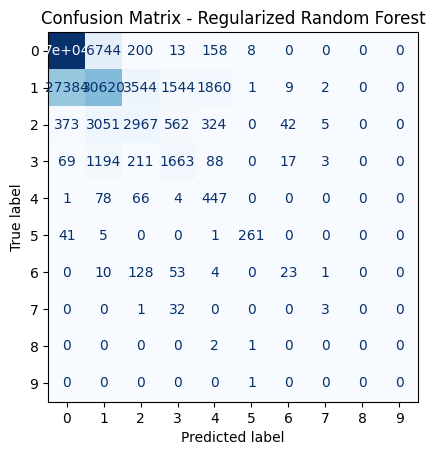

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcolo della matrice di confusione sul validation set
y_pred_rf_reg = rf_reg.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_pred_rf_reg)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8, 8))
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix - Regularized Random Forest")
plt.show()


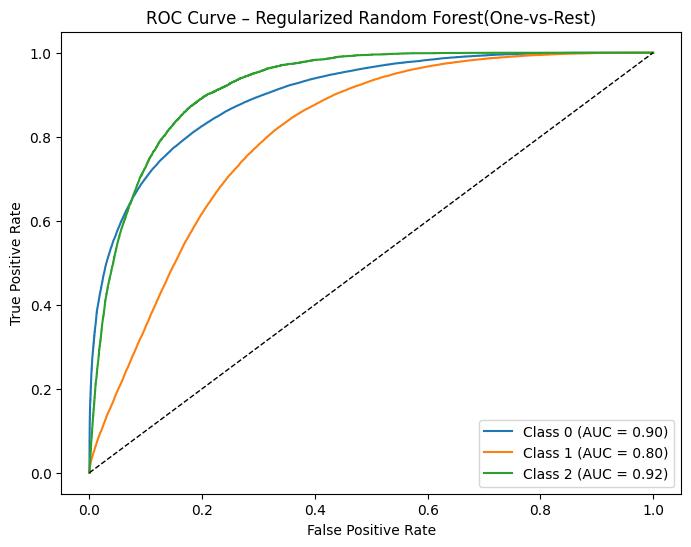

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Binarizzazione delle classi per il calcolo multiclasse
y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
n_classes = y_val_bin.shape[1]

# One-vs-Rest per Random Forest
classifier = OneVsRestClassifier(rf_reg)
y_score = classifier.fit(X_train_scaled, y_train).predict_proba(X_val_scaled)

# Calcolo ROC/AUC per ogni classe
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Grafico ROC per le classi principali
plt.figure(figsize=(8, 6))
for i in range(3):  # solo le prime 3 classi per chiarezza
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve – Regularized Random Forest(One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
